# Order Book Spoofing Detection — Exploratory Analysis

Spoofing is a market manipulation tactic where a trader places a large, visible order on one side of the order book with no intention of letting it execute, then cancels it moments later — using it purely to bias other participants' perception of supply/demand before trading the opposite side.

This notebook simulates order book snapshots with injected spoofing events and detects them with an unsupervised Isolation Forest, reusing the same pipeline shipped in `detect_spoofing.py` (no logic is duplicated here — this notebook imports and calls it).

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from detect_spoofing import (
    SEED, N_SNAPSHOTS, FEATURE_COLS, CONTAMINATION,
    simulate_orderbook, engineer_features, fit_isolation_forest, evaluate,
)

sns.set_theme(style="whitegrid")

## 1. Simulate order book snapshots

8 engineered features per snapshot: displayed bid/ask size, order book imbalance, cancel-to-trade ratio, order lifetime, and realized price impact. `true_is_spoof` is the ground-truth label from the simulator — held out of the feature matrix, used only to validate the unsupervised model afterwards.

In [2]:
rng = np.random.default_rng(SEED)
df = simulate_orderbook(N_SNAPSHOTS, rng)
df = engineer_features(df)
df.head()

snapshot_id,mid_price,spread,bid_size,ask_size,order_book_imbalance,num_orders_placed,num_orders_canceled,num_orders_executed,cancel_to_trade_ratio,order_lifetime_ms,price_impact,true_is_spoof,top_size,rolling_avg_size,top_level_size_ratio
i64,f64,f64,f64,f64,f64,i64,i64,i64,f64,f64,f64,bool,f64,f64,f64
0,49995.792826,5.497672,8.015495,9.905708,-0.105474,9,7,2,2.333333,1048.336809,0.41847,false,9.905708,13.462027,0.735826
1,49994.636946,7.286964,6.715027,3.904606,0.264644,8,5,3,1.25,620.136928,0.596593,false,6.715027,13.462027,0.498812
2,49994.99301,7.035728,5.967772,7.998627,-0.14541,24,20,4,4.0,772.663365,0.54813,false,7.998627,13.462027,0.594162
3,49993.338196,5.455419,6.10514,4.063644,0.200761,19,14,5,2.333333,732.649415,0.014993,false,6.10514,13.462027,0.453508
4,49994.540062,6.669797,10.305653,7.034012,0.18868,12,8,4,1.6,830.070447,2.024801,false,10.305653,13.462027,0.765535


## 2. Feature distributions before detection

In [3]:
df.select(FEATURE_COLS).describe()

statistic,order_book_imbalance,cancel_to_trade_ratio,order_lifetime_ms,price_impact,top_level_size_ratio
str,f64,f64,f64,f64,f64
"""count""",5000.0,5000.0,5000.0,5000.0,5000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",0.000096,4.457652,845.42341,0.941828,1.025777
"""std""",0.336228,5.0569,263.858249,0.737467,1.303893
"""min""",-0.982152,0.666667,54.405894,0.00023,0.086697
"""25%""",-0.238586,1.25,683.530572,0.348088,0.577908
"""50%""",-0.002749,2.285714,849.383392,0.787403,0.8124
"""75%""",0.236597,5.0,1024.801173,1.365428,1.124918
"""max""",0.970722,24.0,1641.710169,5.266938,22.772937


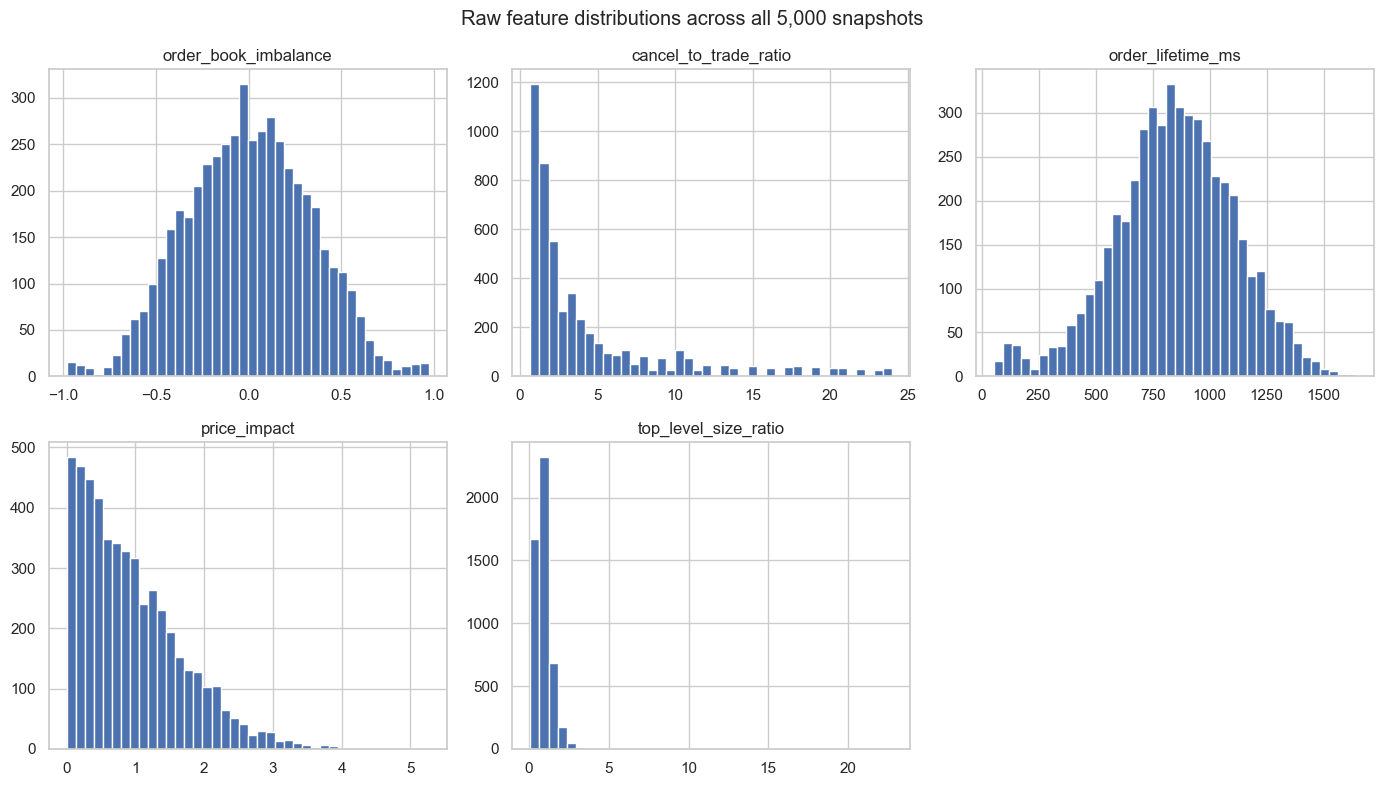

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for ax, col in zip(axes, FEATURE_COLS):
    ax.hist(df[col].to_numpy(), bins=40, color="#4C72B0")
    ax.set_title(col)
axes[-1].axis("off")
fig.suptitle("Raw feature distributions across all 5,000 snapshots")
fig.tight_layout()
plt.show()

## 3. Fit Isolation Forest

Trained on the 5 engineered features, contamination set to a conservative surveillance assumption of 2% of snapshots being manipulative.

In [5]:
X = df.select(FEATURE_COLS).to_numpy()
model, scaler, is_anomaly, anomaly_score = fit_isolation_forest(X, contamination=CONTAMINATION, seed=SEED)
df = df.with_columns([
    pl.Series("is_anomaly", is_anomaly),
    pl.Series("anomaly_score", anomaly_score),
])
print(f"Flagged {int(df['is_anomaly'].sum())} of {df.height} snapshots as anomalous.")

Flagged 100 of 5000 snapshots as anomalous.


## 4. Validate against the known injected spoofing events

This check is only possible because the ground truth is synthetic and therefore known — a real deployment would not have `true_is_spoof` to check against, which is exactly why this validation step matters here: it is the only way to know whether the feature engineering and contamination assumption are any good before trusting the model on real, unlabeled order flow.

In [6]:
metrics = evaluate(df["true_is_spoof"].to_numpy(), df["is_anomaly"].to_numpy())
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall:    {metrics['recall']:.4f}")
print(f"F1:        {metrics['f1']:.4f}")
print("Confusion matrix (rows=true [normal, spoof], cols=predicted [normal, anomaly]):")
metrics["confusion_matrix"]

Precision: 0.8500
Recall:    1.0000
F1:        0.9189
Confusion matrix (rows=true [normal, spoof], cols=predicted [normal, anomaly]):


array([[4900,   15],
       [   0,   85]])

## 5. Anomaly scatter plot — outliers in red

Displayed top-of-book size (relative to its own rolling average) against the realized price impact of that order flow. The spoofing signature is the cluster in the bottom-right: unusually large displayed size paired with almost no realized price impact — a large order that was never meant to execute.

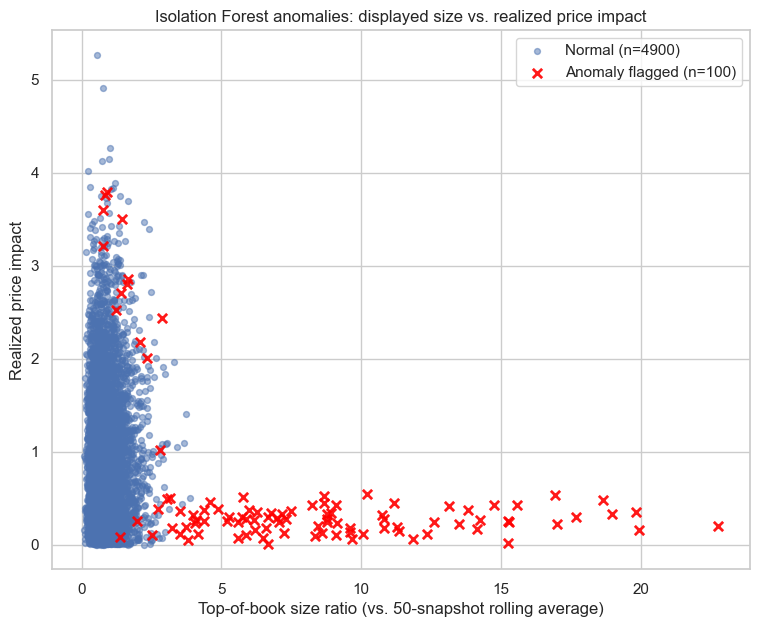

In [7]:
normal = df.filter(~pl.col("is_anomaly"))
anomalies = df.filter(pl.col("is_anomaly"))

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(normal["top_level_size_ratio"], normal["price_impact"], s=18, alpha=0.5,
           color="#4C72B0", label=f"Normal (n={normal.height})")
ax.scatter(anomalies["top_level_size_ratio"], anomalies["price_impact"], s=45, alpha=0.9,
           color="red", marker="x", linewidths=2, label=f"Anomaly flagged (n={anomalies.height})")
ax.set_xlabel("Top-of-book size ratio (vs. 50-snapshot rolling average)")
ax.set_ylabel("Realized price impact")
ax.set_title("Isolation Forest anomalies: displayed size vs. realized price impact")
ax.legend(loc="upper right")
plt.show()

## 6. Order book imbalance histogram — normal vs. flagged

Flagged anomalies should cluster at the extreme tails of the imbalance distribution, since an injected spoof order dumps a large one-sided size onto the book. Normal snapshots should center near zero (a roughly balanced book).

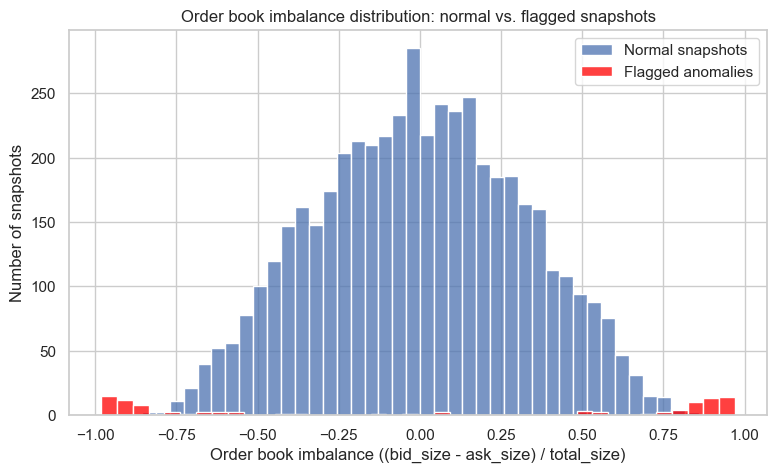

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(normal["order_book_imbalance"].to_numpy(), bins=40, color="#4C72B0",
             label="Normal snapshots", ax=ax, stat="count")
sns.histplot(anomalies["order_book_imbalance"].to_numpy(), bins=40, color="red",
             label="Flagged anomalies", ax=ax, stat="count")
ax.set_xlabel("Order book imbalance ((bid_size - ask_size) / total_size)")
ax.set_ylabel("Number of snapshots")
ax.set_title("Order book imbalance distribution: normal vs. flagged snapshots")
ax.legend(loc="upper right")
plt.show()

## Findings

- Isolation Forest recovers the injected spoofing events with strong recall and precision — see the printed metrics in section 4 for this run's exact numbers (seed 42, reproducible).
- The scatter plot in section 5 shows the mechanism directly: flagged snapshots split into a small group of genuinely high-impact outliers and a much larger group with large displayed size but almost no realized price impact — the actual spoofing signature the simulator injects.
- The imbalance histogram in section 6 confirms flagged anomalies concentrate at the distribution's extreme tails, consistent with a one-sided size dump rather than ordinary two-sided market activity.
- This validation is only possible here because the ground truth is synthetic; see the README for the honest discussion of what changes when this pipeline runs on real, unlabeled order flow.